In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#fetch dataset
adult=fetch_ucirepo(id=2)

#features and target
X=adult.data.features
y=adult.data.targets

#combine into one dataframe
df=pd.concat([X, y], axis=1)

#preview
df.head(15)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [ ]:
#look at shape,info,and income counts
print("Shape;",df.shape)
print("\nInfo:")
df.info()
print("\nIncome Counts:")
print(df['income'].value_counts())

Shape; (48842, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Income Counts:
income
<=50K     24720
<=50K.    12435
>50K       7

In [ ]:
#remove the period from the target column so there are no duplicates
df['income']=df['income'].str.replace('.','',regex=False)
print(df['income'].value_counts())

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [ ]:
#finding which columbs contain '?' to replace them with NaN
(df=='?').sum()
df.replace('?',np.nan,inplace=True)
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [ ]:
#droping all cells with NaN
df=df.dropna()
df.isnull().sum()
df.shape

(45222, 15)

In [ ]:
#using get_dummies to encode into 0s and 1s
df_encoded=pd.get_dummies(df,drop_first=True)
df_encoded.shape

(45222, 97)

In [ ]:
#features (everything except income)
X=df_encoded.drop('income_>50K',axis=1)

#target (income)
y=df_encoded['income_>50K']

#split data (80% train, 20% test)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(36177, 96)
(9045, 96)


In [ ]:
#create model
log_reg=LogisticRegression(max_iter=2000)

#train model
log_reg.fit(X_train,y_train)

#predictions
log_pred=log_reg.predict(X_test)

#evaluate model
print("Accuracy:",accuracy_score(y_test,log_pred))
print("\nClassification Report:")
print(classification_report(y_test,log_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,log_pred))

Accuracy: 0.8470978441127694

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.93      0.90      6745
        True       0.75      0.60      0.67      2300

    accuracy                           0.85      9045
   macro avg       0.81      0.77      0.78      9045
weighted avg       0.84      0.85      0.84      9045


Confusion Matrix:
[[6284  461]
 [ 922 1378]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#create model
dec_tree=DecisionTreeClassifier(random_state=42)

#train model
dec_tree.fit(X_train,y_train)

#predictions
tree_pred=dec_tree.predict(X_test)

#evaluate model
print("Accuracy:",accuracy_score(y_test,tree_pred))
print("\nClassification Report:")
print(classification_report(y_test,tree_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,tree_pred))

Accuracy: 0.8163626312880045

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.88      0.88      6745
        True       0.64      0.64      0.64      2300

    accuracy                           0.82      9045
   macro avg       0.76      0.76      0.76      9045
weighted avg       0.82      0.82      0.82      9045


Confusion Matrix:
[[5915  830]
 [ 831 1469]]


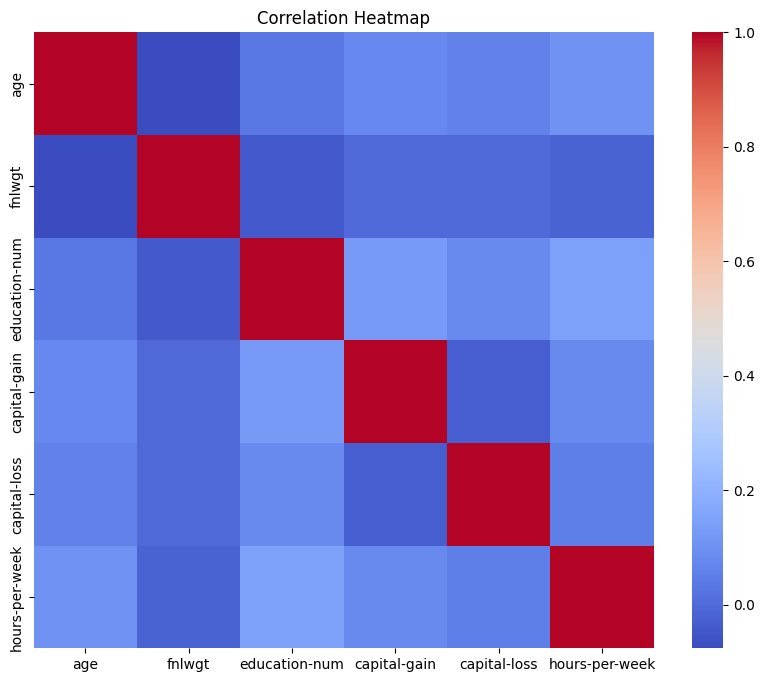

In [ ]:
#creating heatmap based on correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

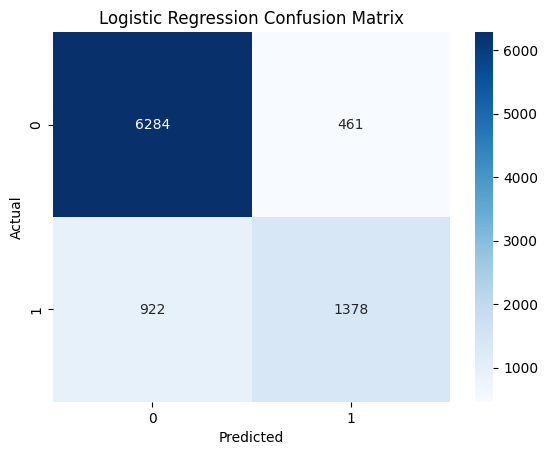

In [ ]:
cm=confusion_matrix(y_test,log_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

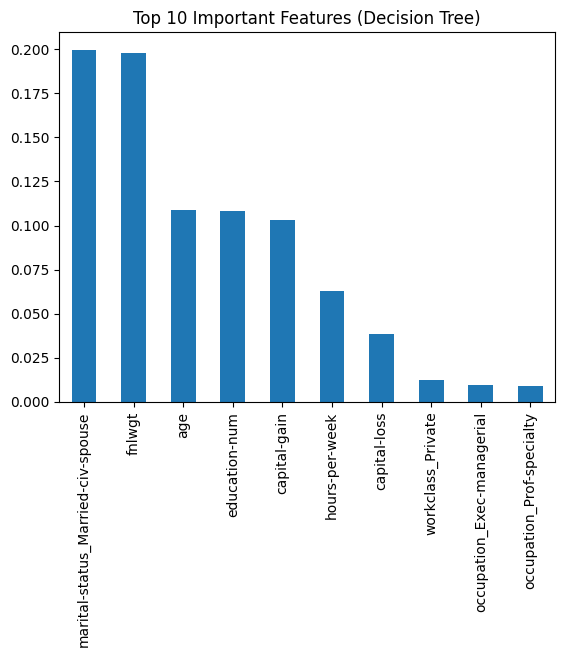

In [ ]:
#bar chart of top 10 most important features according to the decision tree
importance=dec_tree.feature_importances_
feature_names=X.columns

feat_imp=pd.Series(importance,index=feature_names).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features (Decision Tree)")
plt.show()